# Exploration des groupes in.* — Metadata ResStock

In [1]:
import pandas as pd
from pathlib import Path

ROOT           = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

df = pd.read_parquet(DATA_PROCESSED / 'metadata_clean.parquet')
print('Shape total:', df.shape)

# Filtrer uniquement les colonnes in.*
df_in = df[[c for c in df.columns if c.startswith('in.')]]
print('Shape in.* :', df_in.shape)

Shape total: (549971, 391)
Shape in.* : (549971, 165)


In [2]:
# Definition des groupes de colonnes in.* — couvre les 165 colonnes nettoyees
groupes = {

    'Localisation': [
        'in.state', 'in.county', 'in.county_name', 'in.city',
        'in.puma', 'in.census_region', 'in.census_division',
        'in.census_division_recs',
        'in.location_region', 'in.ahs_region', 'in.iso_rto_region',
        'in.weather_file_city', 'in.weather_file_latitude', 'in.weather_file_longitude',
        'in.metropolitan_and_micropolitan_statistical_area', 'in.reeds_balancing_area',
        'in.generation_and_emissions_assessment_region',
        'in.county_and_puma', 'in.county_metro_status',
        'in.puma_metro_status', 'in.aiannh_area',
    ],

    'Zone climatique': [
        'in.ashrae_iecc_climate_zone_2004',
        'in.ashrae_iecc_climate_zone_2004_sub_cz_split',
        'in.building_america_climate_zone',
        'in.cec_climate_zone',
        'in.energystar_climate_zone_2023',
    ],

    'Geometrie batiment': [
        'in.geometry_floor_area', 'in.sqft..ft2', 'in.geometry_stories',
        'in.geometry_attic_type', 'in.geometry_foundation_type',
        'in.geometry_garage', 'in.geometry_wall_type',
        'in.geometry_wall_exterior_finish', 'in.geometry_building_type_recs',
        'in.geometry_building_type_acs', 'in.orientation', 'in.door_area',
        'in.window_areas', 'in.neighbors', 'in.corridor',
        'in.geometry_building_horizontal_location_mf',
        'in.geometry_building_horizontal_location_sfa',
        'in.geometry_building_level_mf',
        'in.geometry_building_number_units_mf',
        'in.geometry_building_number_units_sfa',
    ],

    'Enveloppe thermique': [
        'in.insulation_wall', 'in.insulation_ceiling', 'in.insulation_roof',
        'in.insulation_floor', 'in.insulation_foundation_wall',
        'in.insulation_rim_joist', 'in.insulation_slab',
        'in.infiltration', 'in.air_leakage_to_outside_ach50',
        'in.windows', 'in.interior_shading', 'in.overhangs',
        'in.eaves', 'in.radiant_barrier', 'in.roof_material',
        'in.doors', 'in.ground_thermal_conductivity',
    ],

    'HVAC': [
        'in.hvac_heating_type', 'in.hvac_heating_type_and_fuel',
        'in.hvac_heating_efficiency', 'in.hvac_heating_autosizing_factor',
        'in.hvac_cooling_type', 'in.hvac_cooling_efficiency',
        'in.hvac_cooling_autosizing_factor',
        'in.hvac_cooling_partial_space_conditioning',
        'in.hvac_has_ducts', 'in.hvac_has_shared_system',
        'in.hvac_has_zonal_electric_heating',
        'in.hvac_secondary_heating_type', 'in.hvac_secondary_heating_fuel',
        'in.hvac_secondary_heating_efficiency',
        'in.hvac_secondary_heating_partial_space_conditioning',
        'in.hvac_shared_efficiencies',
        'in.hvac_system_is_faulted', 'in.hvac_system_is_scaled',
        'in.hvac_system_single_speed_ac_airflow',
        'in.hvac_system_single_speed_ac_charge',
        'in.hvac_system_single_speed_ashp_airflow',
        'in.hvac_system_single_speed_ashp_charge',
        'in.heating_fuel',
        'in.heating_setpoint', 'in.heating_setpoint_has_offset',
        'in.heating_setpoint_offset_magnitude', 'in.heating_setpoint_offset_period',
        'in.cooling_setpoint', 'in.cooling_setpoint_has_offset',
        'in.cooling_setpoint_offset_magnitude', 'in.cooling_setpoint_offset_period',
        'in.duct_leakage_and_insulation', 'in.duct_location',
        'in.mechanical_ventilation', 'in.natural_ventilation',
        'in.heating_unavailable_days', 'in.heating_unavailable_period',
        'in.cooling_unavailable_days', 'in.cooling_unavailable_period',
        'in.bathroom_spot_vent_hour', 'in.range_spot_vent_hour',
        'in.dehumidifier',
    ],

    'Eau chaude': [
        'in.water_heater_fuel', 'in.water_heater_efficiency',
        'in.water_heater_in_unit', 'in.water_heater_location',
        'in.hot_water_distribution', 'in.hot_water_fixtures',
    ],

    'Appareils': [
        'in.clothes_dryer', 'in.clothes_dryer_usage_level',
        'in.clothes_washer', 'in.clothes_washer_presence', 'in.clothes_washer_usage_level',
        'in.cooking_range', 'in.cooking_range_usage_level',
        'in.dishwasher', 'in.dishwasher_usage_level',
        'in.refrigerator', 'in.refrigerator_usage_level',
        'in.ceiling_fan',
        'in.lighting', 'in.lighting_interior_use', 'in.lighting_other_use',
        'in.plug_loads', 'in.plug_load_diversity',
        'in.misc_extra_refrigerator', 'in.misc_freezer',
        'in.misc_pool', 'in.misc_pool_heater', 'in.misc_pool_pump',
        'in.misc_hot_tub_spa',
        'in.misc_well_pump',
        'in.misc_gas_fireplace', 'in.misc_gas_grill', 'in.misc_gas_lighting',
        'in.holiday_lighting',
    ],

    'Vehicule electrique': [
        'in.electric_vehicle_ownership', 'in.electric_vehicle_charger',
        'in.electric_vehicle_charge_at_home', 'in.electric_vehicle_battery',
        'in.electric_vehicle_miles_traveled', 'in.electric_vehicle_outlet_access',
    ],

    'Panneau electrique': [
        'in.electric_panel_service_rating..a',
        'in.electric_panel_breaker_space_total_count',
    ],

    'Solaire et stockage': [
        'in.has_pv', 'in.pv_system_size', 'in.pv_orientation', 'in.battery',
    ],

    'Occupants et socio': [
        'in.bedrooms', 'in.occupants', 'in.income',
        'in.federal_poverty_level', 'in.area_median_income',
        'in.representative_income', 'in.state_metro_median_income',
        'in.tenure', 'in.vacancy_status', 'in.usage_level',
        'in.units_represented', 'in.household_has_tribal_persons',
        'in.vintage',
    ],
}

print('Groupes definis :', list(groupes.keys()))
total = sum(len(v) for v in groupes.values())
print(f'Total colonnes dans les groupes : {total}')

# Verifier qu'on ne manque aucune colonne in.*
cols_in = [c for c in df_in.columns]
couvertes = set(c for cols in groupes.values() for c in cols)
manquantes = [c for c in cols_in if c not in couvertes]
print(f'Colonnes in.* non couvertes : {len(manquantes)}')
if manquantes:
    for c in manquantes:
        print(f'  {c}')

Groupes definis : ['Localisation', 'Zone climatique', 'Geometrie batiment', 'Enveloppe thermique', 'HVAC', 'Eau chaude', 'Appareils', 'Vehicule electrique', 'Panneau electrique', 'Solaire et stockage', 'Occupants et socio']
Total colonnes dans les groupes : 164
Colonnes in.* non couvertes : 1
  in.upgrade_name


In [3]:
# Sélection des colonnes les plus intéressantes par groupe (max 3, 1 pour Localisation et Zone climatique)
selection = {
    'Localisation':        ['in.state'],
    'Zone climatique':     ['in.building_america_climate_zone'],
    'Geometrie batiment':  ['in.geometry_floor_area', 'in.geometry_building_type_recs', 'in.geometry_stories'],
    'Enveloppe thermique': ['in.insulation_wall', 'in.air_leakage_to_outside_ach50', 'in.windows'],
    'HVAC':                ['in.hvac_heating_type', 'in.hvac_cooling_type', 'in.heating_setpoint'],
    'Eau chaude':          ['in.water_heater_fuel', 'in.water_heater_efficiency', 'in.water_heater_in_unit'],
    'Appareils':           ['in.clothes_dryer', 'in.refrigerator', 'in.lighting'],
    'Vehicule electrique': [  'in.electric_vehicle_charge_at_home'],
    'Panneau electrique':  ['in.electric_panel_service_rating..a', 'in.electric_panel_breaker_space_total_count'],
    'Solaire et stockage': ['in.has_pv', 'in.battery'],
    'Occupants et socio':  ['in.vintage', 'in.occupants', 'in.income'],
}

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES = Path().resolve().parent.parent / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

def visualiser_groupe(df_g, nom_groupe, colonnes, ncols=4):
    cols = [c for c in colonnes if c in df_g.columns and df_g[c].nunique() > 1]
    if not cols:
        print(f'[{nom_groupe}] aucune colonne a visualiser.')
        return

    if len(cols) > 30: ncols = 6
    elif len(cols) > 20: ncols = 5

    nrows     = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4.2, nrows * 3.2),
                             squeeze=False)
    axes_flat = axes.flatten()

    for idx, col in enumerate(cols):
        ax       = axes_flat[idx]
        n_unique = df_g[col].nunique()
        label    = col.replace('in.', '')
        title    = label if len(label) <= 28 else label[:26] + '..'

        num = pd.to_numeric(df_g[col], errors='coerce')

        # ── Histogramme — colonne numerique continue (> 30 valeurs uniques) ──
        if n_unique > 30 and num.notna().sum() > 100:
            ax.hist(num.dropna(), bins=30, color='#3b82f6', edgecolor='white', linewidth=0.4)
            ax.set_xlabel(label[:20], fontsize=7)
            ax.set_ylabel('Nb batiments', fontsize=7)

        # ── Barres horizontales — colonne categorielle ────────────────────────
        else:
            top = df_g[col].value_counts().head(12)
            labels_y = [str(v)[:26] for v in top.index]
            ax.barh(labels_y, top.values, color='#3b82f6', edgecolor='white', linewidth=0.4)
            ax.invert_yaxis()
            ax.set_xlabel('Nb batiments', fontsize=7)
            ax.xaxis.set_tick_params(labelsize=7)
            ax.yaxis.set_tick_params(labelsize=7)
            if n_unique > 12:
                ax.set_xlabel('Nb batiments (top 12)', fontsize=7)

        ax.set_title(title, fontsize=8.5, fontweight='bold', pad=4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for ax in axes_flat[len(cols):]:
        ax.set_visible(False)

    fig.suptitle(f'Groupe : {nom_groupe}  ({len(cols)} variables)',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    safe = nom_groupe.lower().replace(' ', '_')
    plt.savefig(FIGURES / f'groupe_{safe}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Sauvegarde : groupe_{safe}.png')

In [5]:
def explorer_groupe(df_g, nom_groupe, colonnes):
    cols_ok = [c for c in colonnes if c in df_g.columns]
    print(f'\n{"=" * 80}')
    print(f'  Groupe : {nom_groupe}  ({len(cols_ok)} attributs)')
    print(f'{"=" * 80}')
    print(f'{"Attribut":<40} {"Uniques":>7} {"% null":>7}  {"Top 3 valeurs"}')
    print('-' * 80)
    for col in cols_ok:
        serie    = df_g[col]
        n_unique = serie.nunique()
        pct_null = serie.isnull().mean() * 100
        vc       = serie.value_counts()
        top3     = [str(v)[:20] for v in vc.index[:3]]
        top3_str = ' | '.join(top3)
        label    = col.replace('in.', '')[:38]
        print(f'{label:<40} {n_unique:>7} {pct_null:>6.1f}%  {top3_str}')

## Groupe 1 — Localisation


  Groupe : Localisation  (21 attributs)
Attribut                                 Uniques  % null  Top 3 valeurs
--------------------------------------------------------------------------------
state                                         51    0.0%  CA | TX | FL
county                                      3139    0.0%  G0600370 | G1700310 | G4802010
county_name                                 1874    0.0%  Los Angeles County | Cook County | Orange County
city                                        1106    0.0%  In another census Pl | Not in a census Plac | NY, New York
puma                                        2351    0.0%  G12000500 | G36003805 | G45001102
census_region                                  4    0.0%  South | Midwest | West
census_division                                9    0.0%  South Atlantic | East North Central | Pacific
census_division_recs                          10    0.0%  South Atlantic | East North Central | Pacific
location_region                          

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\eassoumou1\\FlexiMax\\reports\\figures\\groupe_localisation.png'

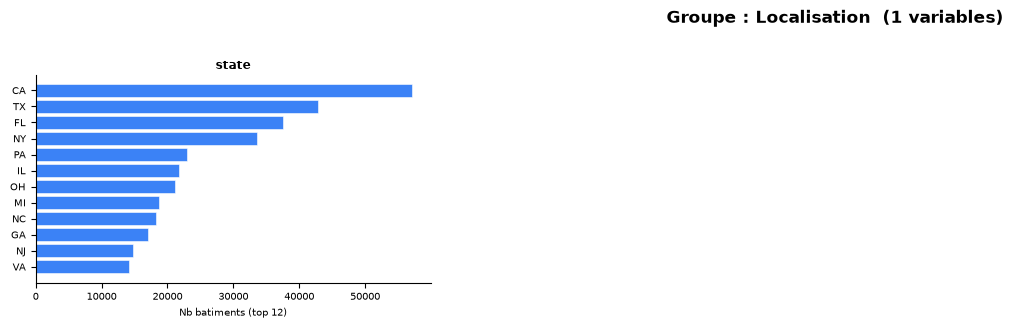

In [6]:
explorer_groupe(df, 'Localisation', groupes['Localisation'])
visualiser_groupe(df, 'Localisation', selection['Localisation'])

## Groupe 2 — Zone climatique

In [ ]:
explorer_groupe(df, 'Zone climatique', groupes['Zone climatique'])
visualiser_groupe(df, 'Zone climatique', selection['Zone climatique'])

## Groupe 3 — Géométrie du bâtiment


  Groupe : Geometrie batiment  (20 attributs)
Attribut                                 Uniques  % null  Top 3 valeurs
--------------------------------------------------------------------------------
geometry_floor_area                            9    0.0%  1000-1499 | 1500-1999 | 750-999
sqft..ft2                                     27    0.0%  1228.0 | 1698.0 | 2179.0
geometry_stories                              18    0.0%  1 | 2 | 3
geometry_attic_type                            4    0.0%  None | Vented Attic | Unvented Attic
geometry_foundation_type                       6    0.0%  Slab | Vented Crawlspace | Unheated Basement
geometry_garage                                4    0.0%  None | 2 Car | 1 Car
geometry_wall_type                             4    0.0%  Wood Frame | Brick | Steel Frame
geometry_wall_exterior_finish                 11    0.0%  Vinyl, Light | Wood, Medium/Dark | Brick, Medium/Dark
geometry_building_type_recs                    5    0.0%  Single-Family Detach 

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\eassoumou1\\FlexiMax\\reports\\figures\\groupe_geometrie_batiment.png'

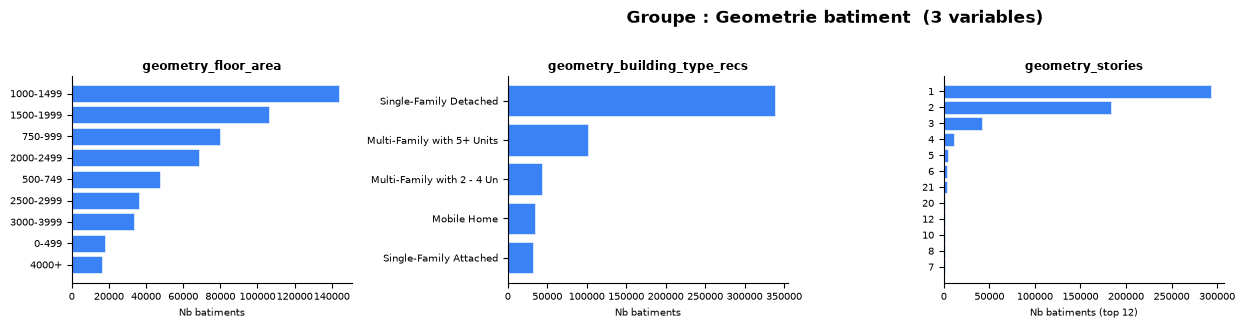

In [7]:
explorer_groupe(df, 'Geometrie batiment', groupes['Geometrie batiment'])
visualiser_groupe(df, 'Geometrie batiment', selection['Geometrie batiment'])

## Groupe 4 — Enveloppe thermique

In [ ]:
explorer_groupe(df, 'Enveloppe thermique', groupes['Enveloppe thermique'])
visualiser_groupe(df, 'Enveloppe thermique', selection['Enveloppe thermique'])

## Groupe 5 — HVAC

In [ ]:
explorer_groupe(df, 'HVAC', groupes['HVAC'])
visualiser_groupe(df, 'HVAC', selection['HVAC'])

## Groupe 6 — Eau chaude

In [ ]:
explorer_groupe(df, 'Eau chaude', groupes['Eau chaude'])
visualiser_groupe(df, 'Eau chaude', selection['Eau chaude'])

## Groupe 7 — Appareils électroménagers

In [ ]:
explorer_groupe(df, 'Appareils', groupes['Appareils'])
visualiser_groupe(df, 'Appareils', selection['Appareils'])

## Groupe 8 — Véhicule électrique

In [ ]:
explorer_groupe(df, 'Vehicule electrique', groupes['Vehicule electrique'])
visualiser_groupe(df, 'Vehicule electrique', selection['Vehicule electrique'])

## Groupe 9 — Panneau électrique

In [ ]:
explorer_groupe(df, 'Panneau electrique', groupes['Panneau electrique'])
visualiser_groupe(df, 'Panneau electrique', selection['Panneau electrique'])

## Groupe 10 — Solaire et stockage

In [ ]:
explorer_groupe(df, 'Solaire et stockage', groupes['Solaire et stockage'])
visualiser_groupe(df, 'Solaire et stockage', selection['Solaire et stockage'])

## Groupe 11 — Occupants et socio-économique

In [ ]:
explorer_groupe(df, 'Occupants et socio', groupes['Occupants et socio'])
visualiser_groupe(df, 'Occupants et socio', selection['Occupants et socio'])

## Résumé — Vue d'ensemble de tous les groupes (11 groupes, 165 colonnes)

In [ ]:
print(f'{"Groupe":30s} | {"Cols":5s} | {"% manquant moyen":18s}')
print('-' * 60)

for nom, cols in groupes.items():
    cols_ok = [c for c in cols if c in df_in.columns]
    pct_null = df_in[cols_ok].isnull().mean().mean() * 100
    print(f'{nom:30s} | {len(cols_ok):5d} | {pct_null:6.1f}%')